# ResNet-50 — autoLRP attribution

ResNet-50 from torchvision (ImageNet weights). Skip connections distribute relevance across both the identity path and the conv block, so heatmaps tend to be more diffuse than VGG.

In [1]:
import sys
sys.path.insert(0, '..')          # examples/showcase: _common
sys.path.insert(0, '../../..')    # repo root: autoLRP (or `pip install -e .`)
import torch
from torchvision.models import resnet50, ResNet50_Weights

import autoLRP as autolrp
from autoLRP import LRPConfig
from _common import load_showcase_images, show_vision_attribution, imagenet_classes

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
model = resnet50(weights=ResNet50_Weights.DEFAULT).eval().to(device)
images = load_showcase_images(device=device)
print(f'Loaded {len(images)} showcase images')

Loaded 1 showcase images


/opt/miniconda3/envs/waleed/lib/python3.12/site-packages/torchvision/models/resnet.py:160: UserWarning: In-place 'add_' remapped to out-of-place 'add' for LRP graph compatibility; the original tensor is NOT modified in place. Set AUTOLRP_NO_INPLACE_REMAP=1 to disable.
  out += identity


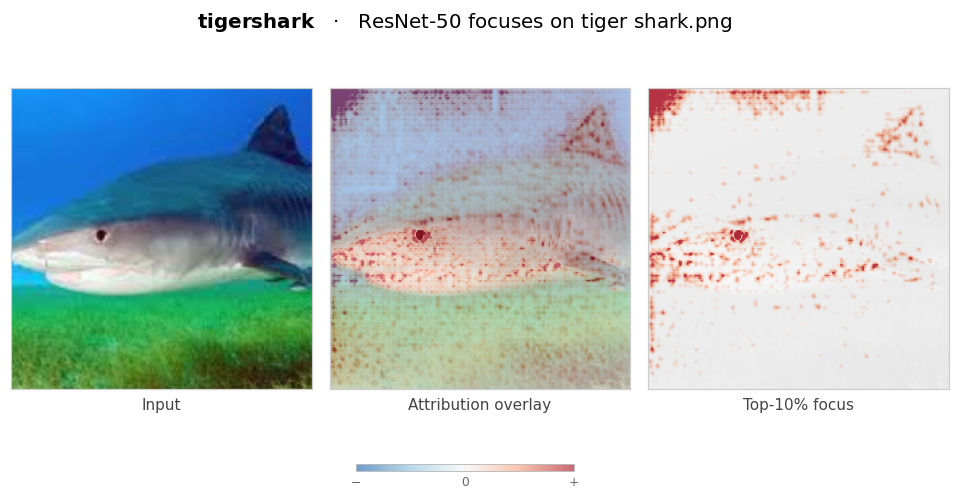

In [3]:
for img, label in images:
    with torch.no_grad():
        pred = model(img).argmax(-1).item()
    pred_name = imagenet_classes()[pred]
    x = autolrp.tensor(img.clone())
    model(x)[0, pred].lrp(config=LRPConfig.composite())
    show_vision_attribution(
        img,
        x.relevance,
        pred_label=pred_name,
        rule_name=f'ResNet-50 focuses on {pred_name.lower().replace(",", "_")}.png'
    )